# ForeverTree LLM panel — headline figures

Headline figures for the H1 comparison (Josh vs Mesa), now driven by the
phase6-v1 scorer schema on the post-refactor k8s execution path:

- **Panel A** — pass rate (`did_run`) by model × target.
- **Panel B** — gate cascade by furthest gate reached.
- **Regression-fit panel** — observed-vs-predicted β, α, R² per cell
  against the spec-faithful reference simulator's acceptance bands.
- **Runtime panel** — `sim_wall_seconds` (pure `./run.sh`) by model ×
  target; the Josh-vs-Mesa runtime comparison from
  [SCORING.md](../SCORING.md).
- **Code / style panel** — `src_loc`, `comment_loc`, `imports_loc`,
  `entropy_bits` per cell.
- **Cost & token panel** — agent-phase OpenRouter spend and tool-call
  activity per cell.
- **Fuzzy judge panel** — Q1 (did the agent actually use the named
  framework?), Q2 (where did it get stuck?), Q3 (does `./run.sh`
  carry the full preprocess + 100×100 contract?) — answered by the
  in-Pod judge ([prompts/FUZZY_JUDGE.md](../prompts/FUZZY_JUDGE.md)).

Data source: `analysis/aggregated.csv`, produced by `analysis/aggregate.py`,
which walks each batch's `runs/<batch>/<cell-id>/workspace/results/scorer.json`
plus the sibling `agent_meta/steps/`. Re-aggregate any time new batches land:

```
uv run analysis/aggregate.py --pattern 'runs/minihl-*'
```

All metric definitions come from [SCORING.md](../SCORING.md).


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# Panel-scope config. Adjust to your batch.
AGGREGATED = Path('aggregated.csv')
# Default to the mini-headline batch + its retry once that lands.
BATCH_FILTER = ['minihl-20260521', 'minihl-20260521-retry']
# Headline panel as of 2026-05-21 (config/models.yaml). `claude` (opus)
# is available for sensitivity runs but isn't part of the current panel.
MODEL_ORDER  = ['sonnet', 'gemma', 'kimi', 'minimax', 'mistral']
TARGET_ORDER = ['josh', 'mesa']
TARGET_COLORS = {'josh': '#2b8cbe', 'mesa': '#e34a33'}
OUT_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)


In [3]:
df = pd.read_csv(AGGREGATED)
if BATCH_FILTER is not None:
    df = df[df['batch_tag'].isin(BATCH_FILTER)].copy()
df = df[df['model'].isin(MODEL_ORDER) & df['target'].isin(TARGET_ORDER)].copy()
print(f'rows: {len(df)}')
print(f'batches: {sorted(df.batch_tag.unique())}')
df.groupby(['model', 'target']).size().unstack(fill_value=0).reindex(index=MODEL_ORDER, columns=TARGET_ORDER)


rows: 21
batches: ['minihl-20260521']


target,josh,mesa
model,,
sonnet,2.0,6.0
gemma,2.0,3.0
kimi,0.0,4.0
minimax,0.0,4.0
mistral,NaN,NaN


In [4]:
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    """Return (point, low, high) for a binomial proportion. n=0 -> (nan, 0, 1)."""
    if n == 0:
        return float('nan'), 0.0, 1.0
    phat = k / n
    denom = 1 + z*z/n
    centre = (phat + z*z/(2*n)) / denom
    halfwidth = z * math.sqrt(phat*(1-phat)/n + z*z/(4*n*n)) / denom
    return phat, max(0.0, centre - halfwidth), min(1.0, centre + halfwidth)


def cascade_level(row) -> int:
    """Furthest gate the cell reached. Mutually exclusive levels 0..3:
       0 = no target conformance
       1 = conformed, did not run cleanly
       2 = did_run, but observed-vs-predicted regression gate failed
       3 = did_run AND regression_fit_ok (full pass)
    Each cell occupies exactly one level."""
    if not bool(row.get('target_conformance')):
        return 0
    if not bool(row.get('did_run')):
        return 1
    if not bool(row.get('regression_fit_ok')):
        return 2
    return 3

df['cascade_level'] = df.apply(cascade_level, axis=1)
df[['model','target','target_conformance','did_run','regression_fit_ok','cascade_level']].head()


,model,target,target_conformance,did_run,regression_fit_ok,cascade_level
0,gemma,josh,True,False,False,1
1,gemma,josh,True,False,False,1
2,gemma,mesa,True,True,False,2
3,gemma,mesa,False,False,False,0
4,gemma,mesa,True,True,True,3


## Panel A — H1: pass rate (`did_run`) by model × target

H1 (EXPERIMENTAL_DESIGN.md): _a higher fraction of Josh implementations will run
and pass validation than Mesa implementations_. Bars show the per-(model, target)
mean of `did_run`; error bars are Wilson 95 % intervals. Labels above bars show `k/N`.


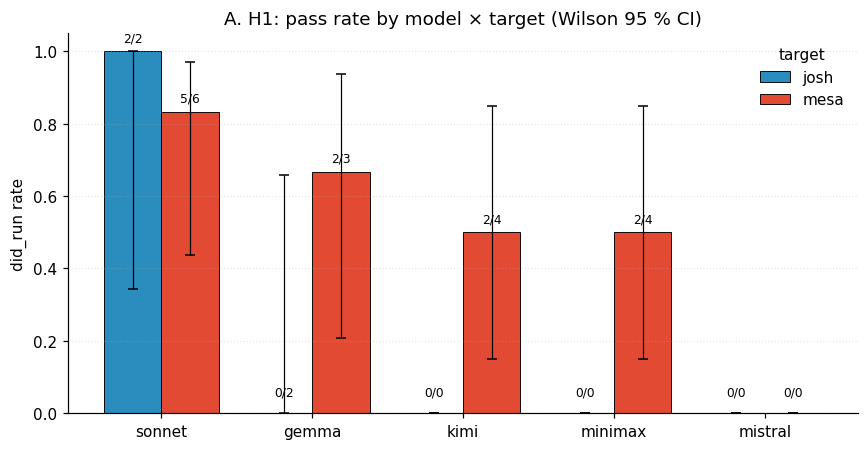

In [5]:
def panel_a(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    width = 0.38
    x = np.arange(len(MODEL_ORDER))
    for i, tgt in enumerate(TARGET_ORDER):
        means, lows, highs, labels = [], [], [], []
        for m in MODEL_ORDER:
            sub = df_in[(df_in.model == m) & (df_in.target == tgt)]
            k = int(sub['did_run'].sum()) if not sub.empty else 0
            n = len(sub)
            phat, lo, hi = wilson_ci(k, n)
            means.append(phat if not math.isnan(phat) else 0)
            lows.append(0 if math.isnan(phat) else phat - lo)
            highs.append(0 if math.isnan(phat) else hi - phat)
            labels.append(f'{k}/{n}' if n else '0/0')
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, label=tgt, color=TARGET_COLORS[tgt],
                      edgecolor='black', linewidth=0.6)
        ax.errorbar(x + offset, means, yerr=[lows, highs], fmt='none',
                    color='black', capsize=3, linewidth=0.8)
        for xi, lbl, m in zip(x + offset, labels, means):
            ax.text(xi, max(m + 0.02, 0.04), lbl, ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel('did_run rate')
    ax.set_ylim(0, 1.05)
    ax.set_title('A. H1: pass rate by model × target (Wilson 95 % CI)')
    ax.legend(title='target', loc='upper right', frameon=False)
    ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, ax = plt.subplots(figsize=(8, 4.2))
panel_a(df, ax)
fig.tight_layout()
plt.show()


## Panel B — Gate cascade: where do cells get stuck?

Each (model, target) cell-group is a stacked bar across four mutually-exclusive
levels:

| Level | Meaning |
|---|---|
| 0 | `target_conformance = False` — agent didn't use the named framework |
| 1 | conformance ✓, `did_run = False` — script crashed or CSV schema wrong |
| 2 | `did_run` ✓, but `regression_fit_ok = False` (β / α / R² outside bands) |
| 3 | full pass — `did_run` ✓ and the spec-faithful regression gate passed |

The phase-6 headline gate is the observed-vs-predicted regression from
[harness/validators/acceptance.py](../harness/validators/acceptance.py) — `β`
should be ~1, `α` near 0, `R²` near 1. Acceptance bands and tolerances live in
[acceptance_ranges.json](../harness/acceptance_ranges.json).


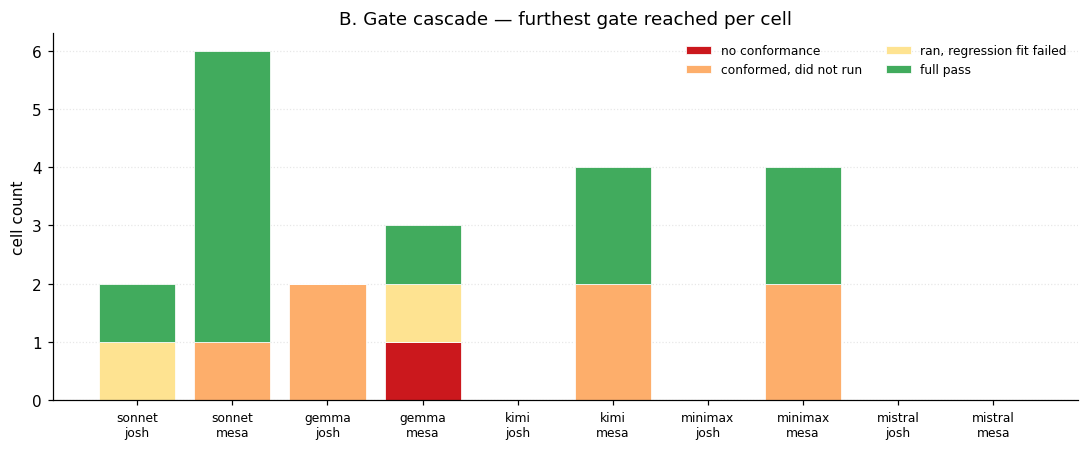

In [6]:
LEVEL_LABELS = {
    0: 'no conformance',
    1: 'conformed, did not run',
    2: 'ran, regression fit failed',
    3: 'full pass',
}
LEVEL_COLORS = {0: '#cb181d', 1: '#fdae6b', 2: '#fee391', 3: '#41ab5d'}


def panel_b(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    groups = [(m, t) for m in MODEL_ORDER for t in TARGET_ORDER]
    counts = {g: {lv: 0 for lv in (0, 1, 2, 3)} for g in groups}
    for g, sub in df_in.groupby(['model', 'target']):
        if g not in counts:
            continue
        for lv, n in sub['cascade_level'].value_counts().items():
            counts[g][int(lv)] = int(n)
    labels = [f'{m}\n{t}' for (m, t) in groups]
    bottoms = np.zeros(len(groups))
    for lv in (0, 1, 2, 3):
        ys = np.array([counts[g][lv] for g in groups])
        ax.bar(labels, ys, bottom=bottoms, color=LEVEL_COLORS[lv],
               edgecolor='white', linewidth=0.5, label=LEVEL_LABELS[lv])
        bottoms += ys
    ax.set_ylabel('cell count')
    ax.set_title('B. Gate cascade — furthest gate reached per cell')
    ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False,
              ncols=2, fontsize=8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.tick_params(axis='x', labelsize=8)


fig, ax = plt.subplots(figsize=(10, 4.2))
panel_b(df, ax)
fig.tight_layout()
plt.show()


## Combined headline figure (Panels A + B)

Stack the H1 pass-rate panel and the gate-cascade panel into one figure
for the paper and save to `figures/headline.{pdf,png}`. Regression-fit
detail and runtime live in their own figures below.


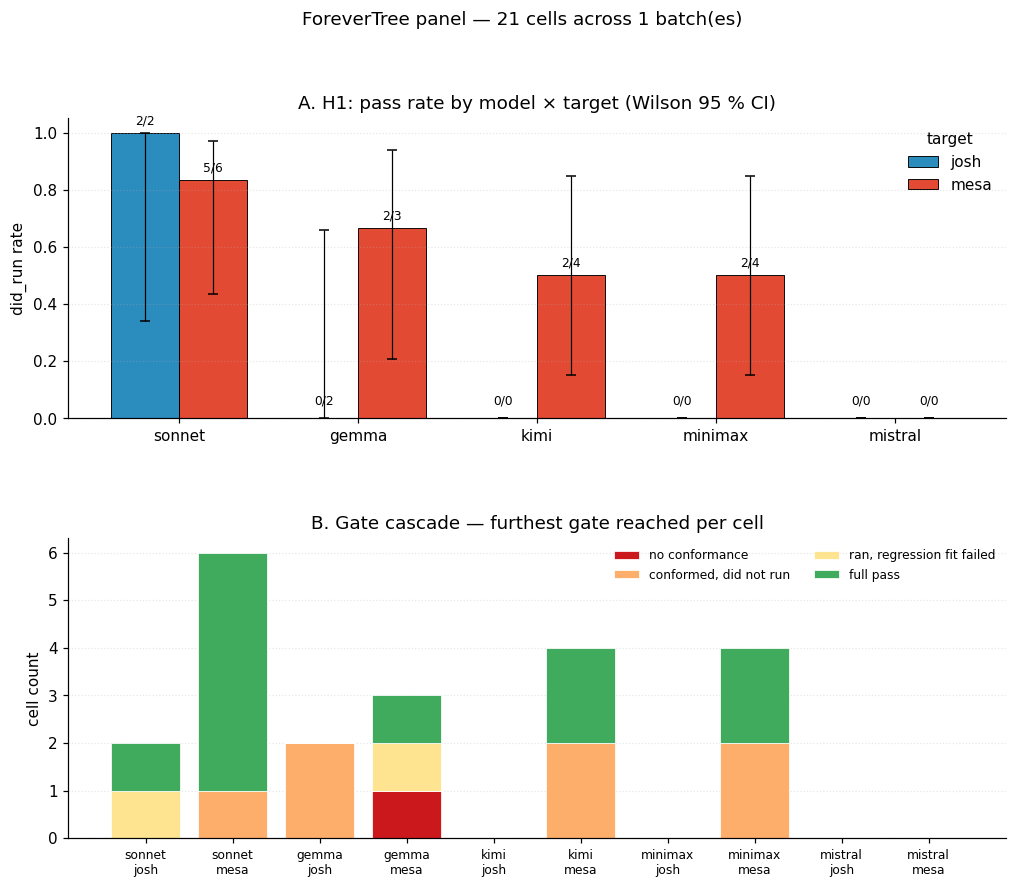

Wrote figures/headline.pdf and figures/headline.png


In [7]:
fig = plt.figure(figsize=(11, 8.5))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.4)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
panel_a(df, ax_a)
panel_b(df, ax_b)
fig.suptitle(
    f'ForeverTree panel — {len(df)} cells across '
    f'{df.batch_tag.nunique()} batch(es)',
    fontsize=12, y=0.995,
)
fig.savefig(OUT_DIR / 'headline.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'headline.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "headline.pdf"} and {OUT_DIR / "headline.png"}')


## Regression-fit panel — observed vs predicted, per cell

The phase-6 ecology gate is an `observed ~ predicted` regression of
year-100 mean height per (cell, replicate) against the spec-faithful
reference simulator's deterministic prediction (see
[harness/spec_model.py](../harness/spec_model.py) and
[data/reference_sim.py](../data/reference_sim.py)).

Three subplots show β, α, R² per cell with the acceptance band overlaid:

- **β ∈ [0.95, 1.05]** — slope ≈ 1 if observed growth tracks predicted.
- **α ∈ [−0.5, 0.5] m** — intercept near 0 if there's no offset bias.
- **R² ≥ 0.95** — variance captured by the deterministic prediction.

A spec-faithful run lands inside all three bands. The fourth subplot
shows the year-100 mean height as a coarse secondary sanity check
(acceptance band from `height_year100` in acceptance_ranges.json).

Only cells with `did_run = True` are shown — the metrics are undefined
for crashed runs.


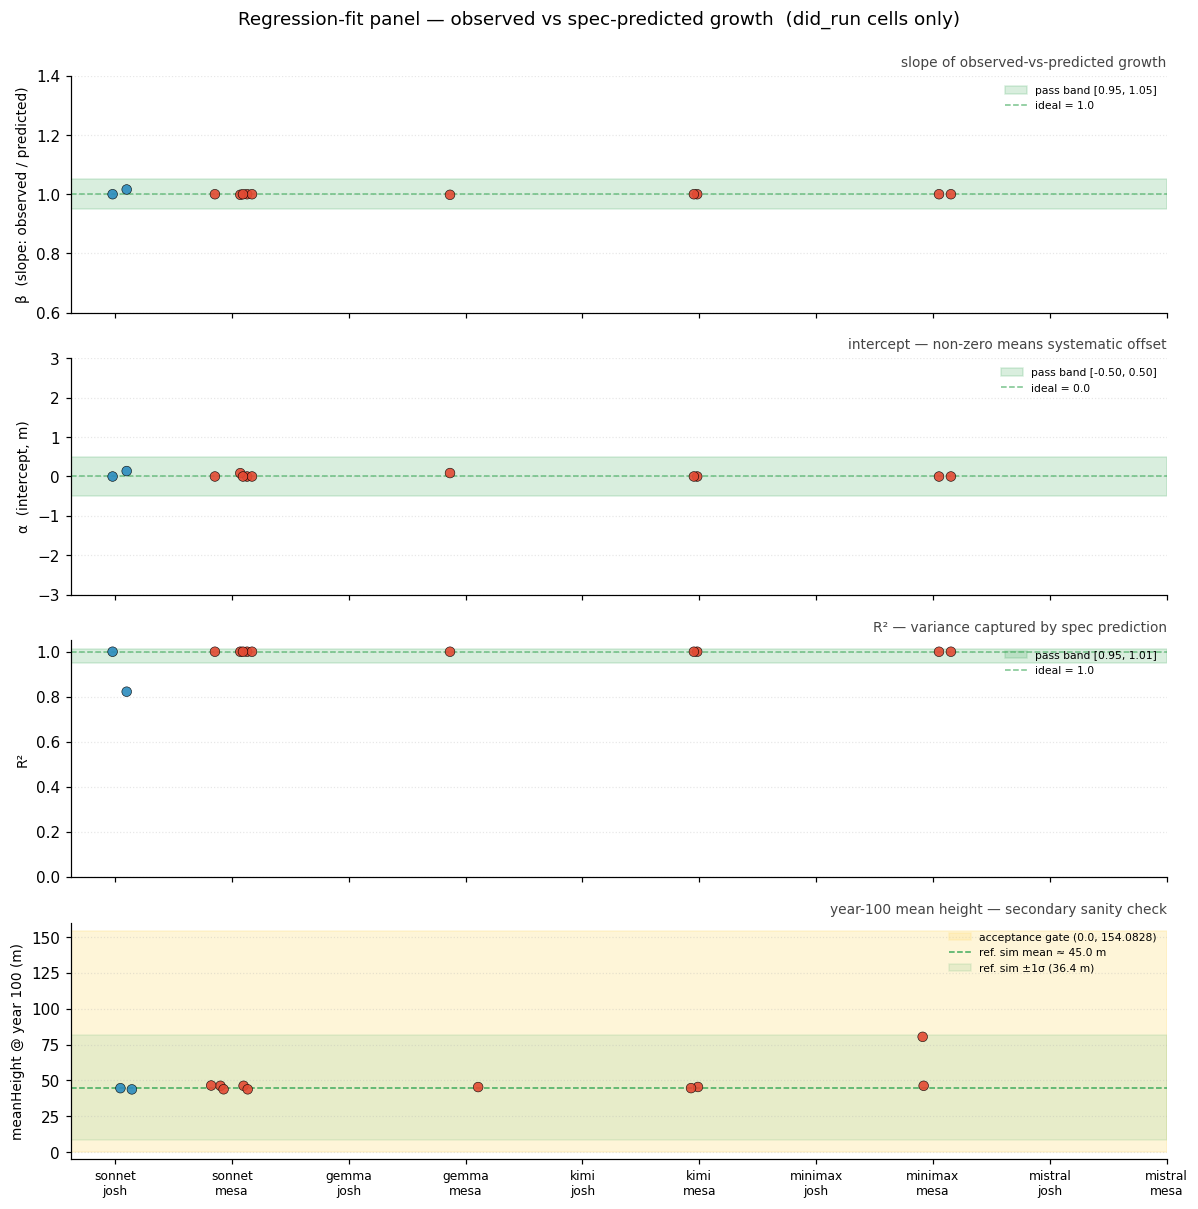

Wrote figures/regression.pdf and figures/regression.png


In [8]:
# Acceptance band targets — copied from harness/acceptance_ranges.json.
# Hard-coded so the notebook runs without re-reading the harness fixture;
# update both if the bands move.
REGRESSION_BANDS = {
    'beta':  {'lo': 0.95, 'hi': 1.05, 'ideal': 1.0,
              'ylabel': 'β  (slope: observed / predicted)',
              'ylim': (0.6, 1.4)},
    'alpha': {'lo': -0.5, 'hi': 0.5, 'ideal': 0.0,
              'ylabel': 'α  (intercept, m)',
              'ylim': (-3.0, 3.0)},
    'r2':    {'lo': 0.95, 'hi': 1.01, 'ideal': 1.0,
              'ylabel': 'R²',
              'ylim': (0.0, 1.05)},
}

# Year-100 mean height secondary sanity band, from acceptance_ranges.json:
HEIGHT_Y100_BAND = (0.0, 154.0828)
HEIGHT_Y100_OBSERVED_MEAN = 45.0101   # reference simulator
HEIGHT_Y100_OBSERVED_STD  = 36.3576


def _scatter_one(ax, df_in, field, band, title=None):
    df_eco = df_in[df_in['did_run'] == True].copy()  # noqa: E712 pandas bool
    df_eco['xkey'] = df_eco['model'] + '\n' + df_eco['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=42)

    # Acceptance band as a pale yellow rectangle; ideal value as dashed line.
    ax.axhspan(band['lo'], band['hi'], color='#41ab5d', alpha=0.20,
               label=f'pass band [{band["lo"]:.2f}, {band["hi"]:.2f}]')
    ax.axhline(band['ideal'], color='#41ab5d', linewidth=1.0,
               linestyle='--', alpha=0.7, label=f'ideal = {band["ideal"]}')

    for g in groups:
        sub = df_eco[df_eco['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        ys = sub[field].astype(float)
        cs = [TARGET_COLORS[t] for t in sub['target']]
        ax.scatter(xs, ys, c=cs, s=40, alpha=0.9, edgecolor='black',
                   linewidth=0.4, zorder=3)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=7)
    ax.set_ylabel(band['ylabel'], fontsize=9)
    ax.set_ylim(*band['ylim'])
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.legend(loc='upper right', fontsize=7, frameon=False)
    if title:
        ax.set_title(title, fontsize=9, loc='right', color='#444')


def panel_regression(df_in, axes):
    _scatter_one(axes[0], df_in, 'regression_beta',  REGRESSION_BANDS['beta'],
                 title='slope of observed-vs-predicted growth')
    _scatter_one(axes[1], df_in, 'regression_alpha', REGRESSION_BANDS['alpha'],
                 title='intercept — non-zero means systematic offset')
    _scatter_one(axes[2], df_in, 'regression_r2',    REGRESSION_BANDS['r2'],
                 title='R² — variance captured by spec prediction')
    # Year-100 mean height sanity panel.
    h_ax = axes[3]
    h_ax.axhspan(*HEIGHT_Y100_BAND, color='#fee391', alpha=0.35,
                 label=f'acceptance gate {HEIGHT_Y100_BAND}')
    h_ax.axhline(HEIGHT_Y100_OBSERVED_MEAN, color='#41ab5d',
                 linewidth=1.0, linestyle='--',
                 label=f'ref. sim mean ≈ {HEIGHT_Y100_OBSERVED_MEAN:.1f} m')
    h_ax.axhspan(HEIGHT_Y100_OBSERVED_MEAN - HEIGHT_Y100_OBSERVED_STD,
                 HEIGHT_Y100_OBSERVED_MEAN + HEIGHT_Y100_OBSERVED_STD,
                 color='#41ab5d', alpha=0.12,
                 label=f'ref. sim ±1σ ({HEIGHT_Y100_OBSERVED_STD:.1f} m)')
    df_eco = df_in[df_in['did_run'] == True].copy()
    df_eco['xkey'] = df_eco['model'] + '\n' + df_eco['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=7)
    for g in groups:
        sub = df_eco[df_eco['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        cs = [TARGET_COLORS[t] for t in sub['target']]
        h_ax.scatter(xs, sub['height_year100_mean'].astype(float),
                     c=cs, s=40, alpha=0.9, edgecolor='black',
                     linewidth=0.4, zorder=3)
    h_ax.set_xticks(range(len(groups)))
    h_ax.set_xticklabels(groups, fontsize=7)
    h_ax.set_ylabel('meanHeight @ year 100 (m)', fontsize=9)
    h_ax.set_ylim(-5, 160)
    h_ax.grid(axis='y', alpha=0.3, linestyle=':')
    h_ax.legend(loc='upper right', fontsize=7, frameon=False)
    h_ax.set_title('year-100 mean height — secondary sanity check',
                   fontsize=9, loc='right', color='#444')


fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
panel_regression(df, axes)
axes[-1].tick_params(axis='x', labelsize=8)
fig.suptitle('Regression-fit panel — observed vs spec-predicted growth  (did_run cells only)',
             y=0.995, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'regression.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'regression.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "regression.pdf"} and {OUT_DIR / "regression.png"}')


## Sim-runtime panel — `sim_wall_seconds` per cell

`sim_wall_seconds` is the time spent inside `./run.sh` only — the scorer
container runs with `--network=none` and no LLM. This is the right
metric for the Josh-vs-Mesa runtime comparison the paper makes; agent /
LLM wall time lives in the cost panel below.

KUBE_WATCH §9 noted "mesa: 5–10 min, josh: 30–60 min" from kubectl wall
clock; this panel shows the scorer-truth version of that observation.
The y-axis is log-scaled because Josh's 100-replicate × 100-year sim is
two orders of magnitude slower than Mesa's at this resolution.

Marker shape encodes `did_run` (filled circle = ran clean, open triangle
= failed — for failed cells, `sim_wall_seconds` reflects whatever
fragment of `./run.sh` got executed before crashing).


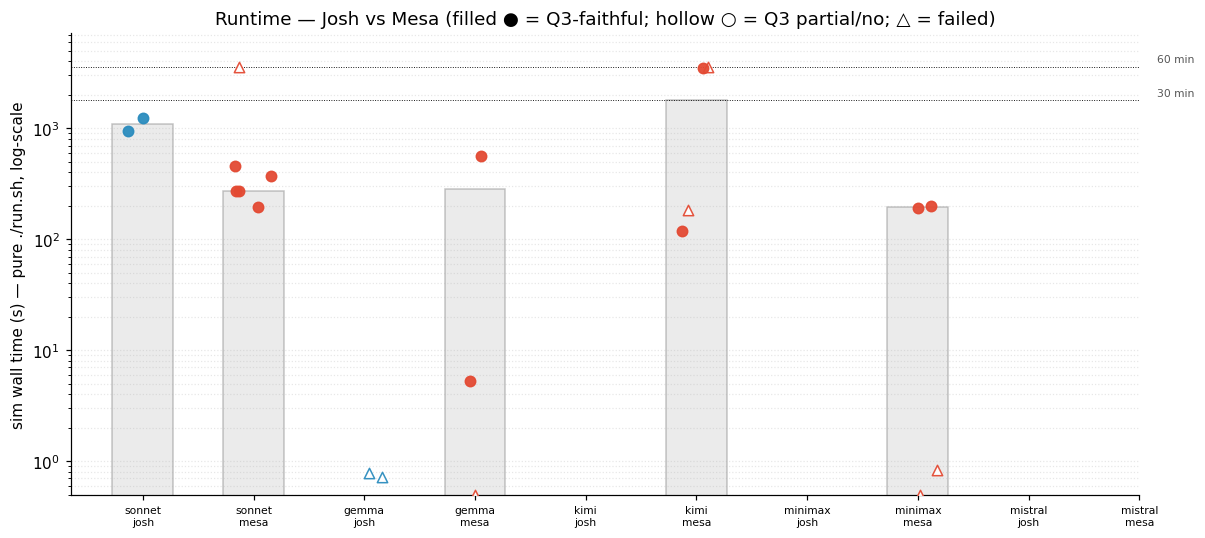

Wrote figures/runtime.pdf and figures/runtime.png


In [9]:
# Q3 marker semantics — fuzzy_q3_answer pulls from scorer.fuzzy.json
# (written by run-judge.sh in the scorer container, or the host-side
# orchestration/run_fuzzy_judge.sh on a pulled batch). Three states:
#   - did_run = False               → open triangle (cell failed)
#   - did_run, q3 ∈ {'partial','no'} → hollow circle (ran, but ./run.sh
#                                       missed preprocess / 100-reps /
#                                       100-years → NOT apples-to-apples)
#   - did_run, q3 = 'yes' or NaN    → filled circle (apples-to-apples
#                                       under the Q3 contract)
def _runtime_marker_style(ran, q3_answer, target):
    if not bool(ran):
        return {"marker": "^", "facecolor": "white",
                "edgecolor": TARGET_COLORS[target], "linewidth": 1.0}
    if q3_answer in ("partial", "no"):
        return {"marker": "o", "facecolor": "white",
                "edgecolor": TARGET_COLORS[target], "linewidth": 1.5}
    return {"marker": "o", "facecolor": TARGET_COLORS[target],
            "edgecolor": TARGET_COLORS[target], "linewidth": 1.0}


def panel_runtime(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    df_r = df_in.copy()
    df_r['xkey'] = df_r['model'] + '\n' + df_r['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=11)

    # Backdrop bar = median over did_run cells.
    for g in groups:
        sub = df_r[(df_r['xkey'] == g) & (df_r['did_run'] == True)]  # noqa: E712
        if sub.empty:
            continue
        med = float(sub['sim_wall_seconds'].median())
        ax.bar(x_index[g], med, width=0.55, color='lightgrey',
               edgecolor='grey', alpha=0.45, zorder=1)

    for g in groups:
        sub = df_r[df_r['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        for x, val, ran, tgt, q3 in zip(xs,
                                          sub['sim_wall_seconds'].astype(float),
                                          sub['did_run'],
                                          sub['target'],
                                          sub.get('fuzzy_q3_answer', pd.Series([None]*len(sub)))):
            style = _runtime_marker_style(ran, q3, tgt)
            y_plot = max(float(val), 0.5)
            ax.scatter([x], [y_plot], s=46, alpha=0.95, zorder=3,
                       marker=style["marker"], c=[style["facecolor"]],
                       edgecolor=style["edgecolor"], linewidth=style["linewidth"])

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=7)
    ax.set_yscale('log')
    ax.set_ylim(0.5, 7200)
    ax.set_ylabel('sim wall time (s) — pure ./run.sh, log-scale')
    ax.grid(axis='y', alpha=0.3, linestyle=':', which='both')
    ax.set_title('Runtime — Josh vs Mesa (filled ● = Q3-faithful; hollow ○ = Q3 partial/no; △ = failed)')

    for sec, lbl in ((1800, '30 min'), (3600, '60 min')):
        ax.axhline(sec, color='black', linewidth=0.6, linestyle=':')
        ax.text(len(groups) - 0.5, sec * 1.05, lbl, fontsize=7, va='bottom',
                ha='right', color='#555')


fig, ax = plt.subplots(figsize=(11, 5))
panel_runtime(df, ax)
fig.tight_layout()
fig.savefig(OUT_DIR / 'runtime.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'runtime.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "runtime.pdf"} and {OUT_DIR / "runtime.png"}')


## Code / style panel — LOC, imports, comments, token entropy

EXPERIMENTAL_DESIGN.md predicts that Josh implementations should be *more
concise* than Mesa ones — the DSL has fewer free decisions, fewer scaffolding
files, and a more direct spec-to-executable mapping. Four metrics from
SCORING.md make this visible per cell:

- **`src_loc`** — lines of generated source. `.jshd` binary preprocessed
  data is excluded ([harness/_files.py](../harness/_files.py)).
- **`comment_loc`** — lines that are pure comments. The master prompt
  asks for "self-documenting, wherever possible, with comments minimized"
  (BASE_PROMPT.md §Style), so this also doubles as a prompt-adherence
  signal.
- **`imports_loc`** — `import` statements only. Mesa needs a much wider
  imports surface than Josh (a `.josh` file declares its modules
  natively).
- **`entropy_bits`** — token-level Shannon entropy of the generated code
  via tiktoken's `cl100k_base`. Higher = more varied vocabulary; very low
  values often indicate boilerplate-heavy or near-empty files.

Marker shape encodes `did_run` (filled circle = ran cleanly; open
triangle = failed). A cell at `src_loc=0` with an open triangle is
"agent never engaged at all".


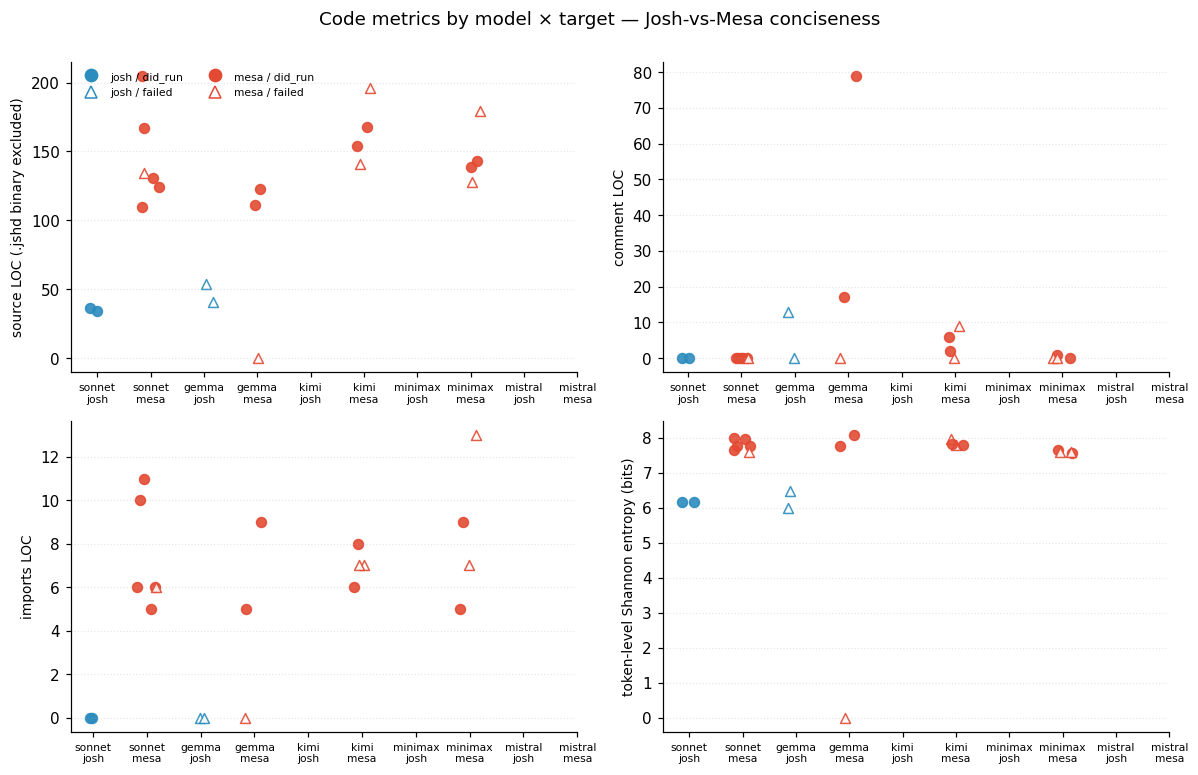

n  src_loc_median  src_loc_max  comment_loc_median  \
model   target                                                       
sonnet  josh    2            35.0           36                 0.0   
        mesa    6           132.5          205                 0.0   
gemma   josh    2            47.5           54                 6.5   
        mesa    3           111.0          123                17.0   
kimi    josh    0             0.0            0                 0.0   
        mesa    4           161.0          196                 4.0   
minimax josh    0             0.0            0                 0.0   
        mesa    4           141.0          179                 0.0   
mistral josh    0             0.0            0                 0.0   
        mesa    0             0.0            0                 0.0   

                imports_loc_median  entropy_bits_median  
model   target                                           
sonnet  josh                   0.0                 6.16  
        mesa                   6.0                 7.76  
gemma   josh                   0.0                 6.24  
        mesa                   5.0                 7.78  
kimi    josh                   0.0                 0.00  
        mesa                   7.0                 7.81  
minimax josh                   0.0                 0.00  
        mesa                   8.0                 7.59  
mistral josh                   0.0                 0.00  
        mesa                   0.0                 0.00

In [10]:
CODE_FIELDS = [
    ('src_loc',      'source LOC (.jshd binary excluded)', None),
    ('comment_loc',  'comment LOC',                         None),
    ('imports_loc',  'imports LOC',                         None),
    ('entropy_bits', 'token-level Shannon entropy (bits)',  None),
]


def panel_code(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_code = df_in.copy()
    df_code['xkey'] = df_code['model'] + '\n' + df_code['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=11)

    for ax, (field, ylabel, _) in zip(axes.flat, CODE_FIELDS):
        for g in groups:
            sub = df_code[df_code['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                ax.scatter([x], [val], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle=':')

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['josh'],
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / failed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['mesa'],
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / failed'),
    ]
    axes.flat[0].legend(handles=legend_handles, loc='upper left',
                        fontsize=7, frameon=False, ncols=2)


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_code(df, axes)
fig.suptitle('Code metrics by model × target — Josh-vs-Mesa conciseness',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'code.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'code.png', bbox_inches='tight')
plt.show()

# Companion table — medians + N so the figure has a number to point at.
loc_tbl = (df.groupby(['model', 'target'])
             .agg(n=('src_loc', 'size'),
                  src_loc_median=('src_loc', 'median'),
                  src_loc_max=('src_loc', 'max'),
                  comment_loc_median=('comment_loc', 'median'),
                  imports_loc_median=('imports_loc', 'median'),
                  entropy_bits_median=('entropy_bits', 'median'))
             .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                       names=['model', 'target']),
                      fill_value=0))
loc_tbl.round(2)


## Agent cost & activity — full agent-phase spend

The agent-phase OpenRouter spend and tool-call activity per cell, summed
across all 8 per-step session exports under
`agent_meta/steps/step_NN/session_export.json`. The cell-level
`agent_meta/session_export.json` is final-step-only and under-counts
whole-cell totals by ~6×; the aggregator does the per-step rollup.

| Column | What it measures |
|---|---|
| `agent_wall_seconds` | first step's `started_at` → last step's `ended_at` across all 8 opencode invocations |
| `agent_cost_usd` | sum of `info.cost` across the 8 per-step exports |
| `agent_tool_calls` | sum of `parts[type=tool]` counts across all 8 step exports |

Marker shape encodes `did_run` (filled = ran cleanly; open triangle =
failed). The sim-runtime panel above isolates `./run.sh` time; this
panel is about LLM-driven activity.


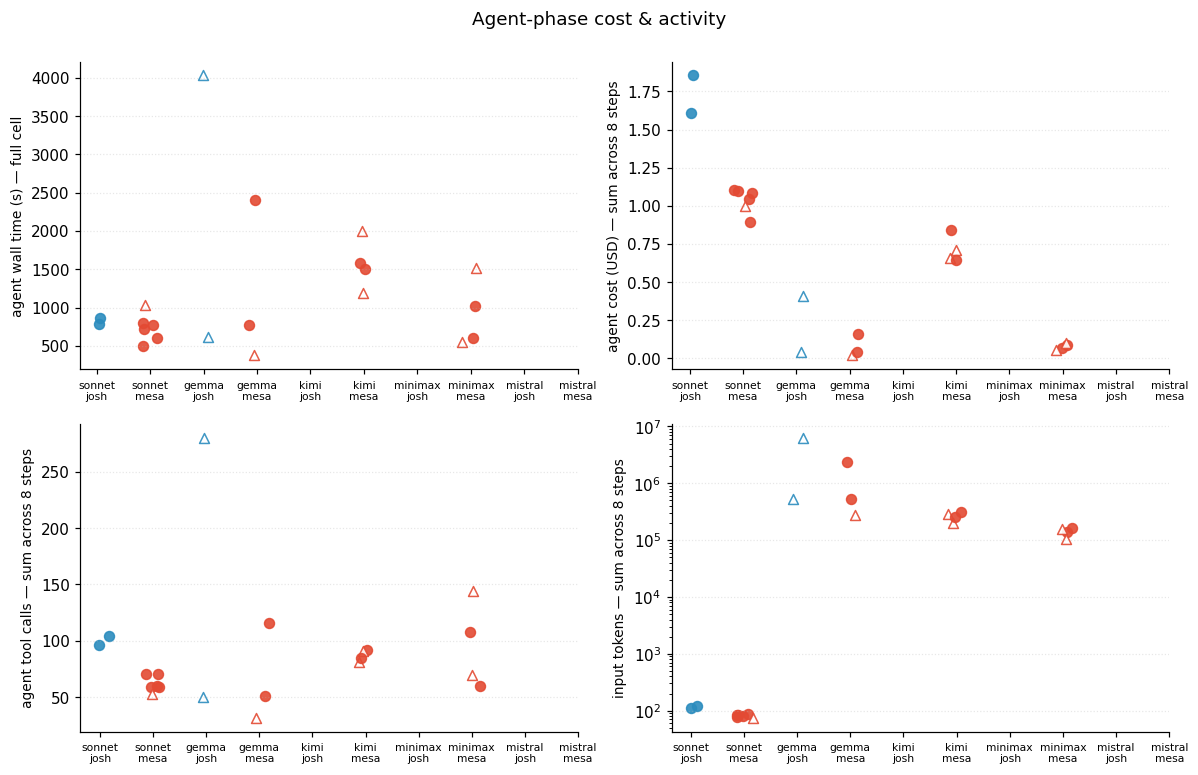

=== Per-(model, target) cost & timing summary ===
                n  ran  sim_wall_med  agent_wall_min  cost_usd_mean  cost_usd_max  tool_calls_mean  in_tokens_k  cache_read_M
model   target                                                                                                               
sonnet  josh    2    2       1092.91            13.7           1.73          1.85           100.00          0.1          2.69
        mesa    6    5        321.92            12.3           1.04          1.11            62.17          0.1          1.32
gemma   josh    2    0          0.75            38.7           0.22          0.41           165.00       3440.7          1.84
        mesa    3    2          5.25            19.8           0.07          0.16            66.33       1060.8          0.59
kimi    josh    0    0          0.00             0.0           0.00          0.00             0.00          0.0          0.00
        mesa    4    2       1821.79            26.2           0.71 

In [11]:
COST_FIELDS = [
    ('agent_wall_seconds',   'agent wall time (s) — full cell',         'linear'),
    ('agent_cost_usd',       'agent cost (USD) — sum across 8 steps',   'linear'),
    ('agent_tool_calls',     'agent tool calls — sum across 8 steps',   'linear'),
    ('agent_tokens_input',   'input tokens — sum across 8 steps',       'log'),
]


def panel_cost(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_c = df_in.copy()
    df_c['xkey'] = df_c['model'] + '\n' + df_c['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=23)

    for ax, (field, ylabel, scale) in zip(axes.flat, COST_FIELDS):
        for g in groups:
            sub = df_c[df_c['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                # log scale needs a positive floor.
                y_plot = max(float(val), 1) if scale == 'log' else float(val)
                ax.scatter([x], [y_plot], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_yscale(scale)
        ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_cost(df, axes)
fig.suptitle('Agent-phase cost & activity', y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'cost_walltime.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'cost_walltime.png', bbox_inches='tight')
plt.show()

cost_tbl = (df.groupby(['model', 'target'])
              .agg(n=('did_run', 'size'),
                   ran=('did_run', 'sum'),
                   sim_wall_med=('sim_wall_seconds', 'median'),
                   agent_wall_min=('agent_wall_seconds',
                                    lambda s: round(s.mean() / 60, 1)),
                   cost_usd_mean=('agent_cost_usd', 'mean'),
                   cost_usd_max=('agent_cost_usd', 'max'),
                   tool_calls_mean=('agent_tool_calls', 'mean'),
                   in_tokens_k=('agent_tokens_input',
                                 lambda s: round(s.mean() / 1000, 1)),
                   cache_read_M=('agent_tokens_cache_read',
                                  lambda s: round(s.mean() / 1_000_000, 2)))
              .reindex(index=pd.MultiIndex.from_product(
                          [MODEL_ORDER, TARGET_ORDER], names=['model', 'target']),
                       fill_value=0))
print('=== Per-(model, target) cost & timing summary ===')
print(cost_tbl.round(2).to_string())
print()
total_cost = df['agent_cost_usd'].fillna(0).sum()
total_agent_h = df['agent_wall_seconds'].fillna(0).sum() / 3600
total_sim_s = df['sim_wall_seconds'].fillna(0).sum()
total_tools = int(df['agent_tool_calls'].fillna(0).sum())
print(f'BATCH TOTAL: ${total_cost:.2f} | '
      f'{total_agent_h:.1f} agent-hours | '
      f'{total_sim_s:.0f} sim-seconds | '
      f'{total_tools} tool calls')


## Fuzzy-judge readout — Q1 / Q2 / Q3 per cell

The in-Pod LLM judge (`/opt/run-judge.sh` in the scorer container; see
[prompts/FUZZY_JUDGE.md](../prompts/FUZZY_JUDGE.md) for the contract)
answers three questions per cell against the agent's workspace,
transcript, and `scorer.json`:

- **Q1.** Did the agent actually use the named target framework as the
  primary modelling vehicle? `yes` / `partial` / `no`. Catches the
  `target_conformance = True` loophole where the agent imports the
  framework but does the real work in plain numpy.
- **Q2.** Where did the agent get stuck? Free text 2–4 sentences,
  surfacing failure modes the mechanical scorer can't describe.
- **Q3.** Does `./run.sh` carry preprocess + 100 replicates +
  2024..2123? `yes` / `partial` / `no`. **Load-bearing for the runtime
  panel above** — a cell answering `partial`/`no` isn't
  apples-to-apples on `sim_wall_seconds`, and is rendered with a
  hollow marker in that figure.

Cells from pre-judge batches show empty fuzzy columns; the section
renders empty rows for those cells without erroring.


In [12]:
import textwrap

Q_GLYPH = {'yes': '✓', 'no': '✗', 'partial': '~'}


def _wrap(text, width=92, indent='      '):
    if not isinstance(text, str) or not text.strip():
        return '(none)'
    return ('\n' + indent).join(textwrap.wrap(text.strip(), width=width)) or '(none)'


def _glyph(answer):
    return Q_GLYPH.get(answer, '?')


# Pivot of Q1 + Q3 distributions — quick scan of how many cells passed
# each judge gate.
def _distribution(df_in, col):
    p = (df_in.assign(present=1)
              .pivot_table(index=['model', 'target'],
                           columns=col,
                           values='present',
                           aggfunc='sum',
                           fill_value=0))
    for ans in ('yes', 'partial', 'no'):
        if ans not in p.columns:
            p[ans] = 0
    p = p[['yes', 'partial', 'no']]
    return p.reindex(
        index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                          names=['model', 'target']),
        fill_value=0)


fuzzy_present = df['fuzzy_q1_answer'].notna() & (df['fuzzy_q1_answer'] != '')
n_judged = int(fuzzy_present.sum())
print(f'cells with fuzzy data: {n_judged} / {len(df)}')

if n_judged == 0:
    print('(no scorer.fuzzy.json files present — re-run with the scorer image '
          'that includes run-judge.sh, or invoke '
          'orchestration/run_fuzzy_judge.sh against the pulled batch.)')
else:
    print()
    print('=== Q1 distribution — did the agent use the named framework? ===')
    print(_distribution(df[fuzzy_present], 'fuzzy_q1_answer'))
    print()
    print('=== Q3 distribution — does ./run.sh carry the full workload? ===')
    print(_distribution(df[fuzzy_present], 'fuzzy_q3_answer'))
    print()
    parse_errs = df[df['fuzzy_parse_error'].notna() & (df['fuzzy_parse_error'] != '')]
    if not parse_errs.empty:
        print(f'Parse errors on {len(parse_errs)} cell(s):')
        for _, row in parse_errs.iterrows():
            print(f"  - {row['run_id']}: {str(row['fuzzy_parse_error'])[:120]}")
        print()
    print('=== Per-cell judge text (sorted by model, target, Q3) ===')
    print()
    ordered = df[fuzzy_present].assign(
        _m=df['model'].map({m: i for i, m in enumerate(MODEL_ORDER)}),
        _t=df['target'].map({t: i for i, t in enumerate(TARGET_ORDER)}),
        _q3=df['fuzzy_q3_answer'].map({'yes': 0, 'partial': 1, 'no': 2}).fillna(3),
    ).sort_values(['_m', '_t', '_q3', 'run_id'])

    for _, row in ordered.iterrows():
        q1g = _glyph(row['fuzzy_q1_answer'])
        q3g = _glyph(row['fuzzy_q3_answer'])
        h100 = row['height_year100_mean']
        h100_s = f'{h100:.1f}' if pd.notna(h100) else '—'
        header = (
            f"[Q1 {q1g}] [Q3 {q3g}] {row['model']:<8s} {row['target']:<5s} "
            f"did_run={'Y' if row['did_run'] else 'N'}  "
            f"fit_ok={'Y' if row['regression_fit_ok'] else 'N'}  "
            f"h100={h100_s}m  "
            f"sim={row['sim_wall_seconds']:.0f}s"
        )
        print(header)
        print(f"   Q1: {_wrap(row.get('fuzzy_q1_justification'))}")
        print(f"   Q2: {_wrap(row.get('fuzzy_q2_observations'))}")
        print(f"   Q3: {_wrap(row.get('fuzzy_q3_justification'))}")
        print()


cells with fuzzy data: 0 / 21
(no scorer.fuzzy.json files present — re-run with the scorer image that includes run-judge.sh, or invoke orchestration/run_fuzzy_judge.sh against the pulled batch.)


### Appendix: per-(model, target) summary table

Companion to the figures for the paper text — k/N pass rates and per-gate
counts.


In [13]:
tbl = (df.groupby(['model', 'target'])
         .agg(n=('did_run', 'size'),
              did_run=('did_run', 'sum'),
              conformed=('target_conformance', 'sum'),
              fit_ok=('regression_fit_ok', 'sum'),
              height_in_range=('height_in_range', 'sum'))
         .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                    names=['model', 'target']),
                  fill_value=0))
tbl['did_run_rate'] = (tbl['did_run'] / tbl['n']).round(2)
tbl['conform_rate'] = (tbl['conformed'] / tbl['n']).round(2)
tbl['fit_ok_rate']  = (tbl['fit_ok']  / tbl['n']).round(2)
tbl


n  did_run  conformed  fit_ok  height_in_range  did_run_rate  \
model   target                                                                 
sonnet  josh    2        2          2       1                2          1.00   
        mesa    6        5          6       6                6          0.83   
gemma   josh    2        0          2       0                0          0.00   
        mesa    3        2          2       1                1          0.67   
kimi    josh    0        0          0       0                0           NaN   
        mesa    4        2          4       3                3          0.50   
minimax josh    0        0          0       0                0           NaN   
        mesa    4        2          4       4                4          0.50   
mistral josh    0        0          0       0                0           NaN   
        mesa    0        0          0       0                0           NaN   

                conform_rate  fit_ok_rate  
model   target                             
sonnet  josh            1.00         0.50  
        mesa            1.00         1.00  
gemma   josh            1.00         0.00  
        mesa            0.67         0.33  
kimi    josh             NaN          NaN  
        mesa            1.00         0.75  
minimax josh             NaN          NaN  
        mesa            1.00         1.00  
mistral josh             NaN          NaN  
        mesa             NaN          NaN